# Interpretable Credit Scoring — XGBoost + SHAP

**Author:** Vishalini Satheesh  
**Institution:** Anna University, College of Engineering Guindy  
**Specialisation:** M.E. CSE - Operational Research  

## Problem Statement
Banks use ML models to decide who gets credit. RBI's Model Risk Management 
guidelines require these decisions to be explainable. This notebook builds 
an XGBoost credit scoring model and uses SHAP to explain every prediction — 
at both the global (portfolio) and local (individual customer) level.

## Connection to M.E. Research
SHAP explains at the feature level. My CDT/ACD thesis extends this to 
human-understandable *concepts* — making explanations accessible to 
regulators and non-technical stakeholders. Both approaches are discussed here.

In [1]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

print("All imports successful ✓")

All imports successful ✓


In [3]:
pip install xlrd

Note: you may need to restart the kernel to use updated packages.


In [4]:
import urllib.request
import os

# Download dataset if not already present
data_path = '../data/credit_default.xls'

if not os.path.exists(data_path):
    print("Downloading dataset...")
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"
    urllib.request.urlretrieve(url, data_path)
    print("Downloaded ✓")
else:
    print("Dataset already exists ✓")

# Load — header=1 skips the first row which is a merged title row
df = pd.read_excel(data_path, header=1)

# Rename target column (it has a space in the original)
df.rename(columns={'default payment next month': 'default'}, inplace=True)

print(f"\nShape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Dataset already exists ✓

Shape: (30000, 25)
Columns: ['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default']


In [5]:
print("=== First 5 rows ===")
display(df.head())

print("\n=== Data types ===")
print(df.dtypes)

print("\n=== Basic statistics ===")
display(df.describe())

print("\n=== Missing values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values ✓")

=== First 5 rows ===


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0



=== Data types ===
ID           int64
LIMIT_BAL    int64
SEX          int64
EDUCATION    int64
MARRIAGE     int64
AGE          int64
PAY_0        int64
PAY_2        int64
PAY_3        int64
PAY_4        int64
PAY_5        int64
PAY_6        int64
BILL_AMT1    int64
BILL_AMT2    int64
BILL_AMT3    int64
BILL_AMT4    int64
BILL_AMT5    int64
BILL_AMT6    int64
PAY_AMT1     int64
PAY_AMT2     int64
PAY_AMT3     int64
PAY_AMT4     int64
PAY_AMT5     int64
PAY_AMT6     int64
default      int64
dtype: object

=== Basic statistics ===


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,15000.50,167484.32,1.60,1.85,1.55,35.49,-0.02,-0.13,-0.17,-0.22,-0.27,-0.29,51223.33,49179.08,47013.15,43262.95,40311.40,38871.76,5663.58,5921.16,5225.68,4826.08,4799.39,5215.50,0.22
std,8660.40,129747.66,0.49,0.79,0.52,9.22,1.12,1.20,1.20,1.17,1.13,1.15,73635.86,71173.77,69349.39,64332.86,60797.16,59554.11,16563.28,23040.87,17606.96,15666.16,15278.31,17777.47,0.42
min,1.00,10000.00,1.00,0.00,0.00,21.00,-2.00,-2.00,-2.00,-2.00,-2.00,-2.00,-165580.00,-69777.00,-157264.00,-170000.00,-81334.00,-339603.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,7500.75,50000.00,1.00,1.00,1.00,28.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,3558.75,2984.75,2666.25,2326.75,1763.00,1256.00,1000.00,833.00,390.00,296.00,252.50,117.75,0.00
50%,15000.50,140000.00,2.00,2.00,2.00,34.00,0.00,0.00,0.00,0.00,0.00,0.00,22381.50,21200.00,20088.50,19052.00,18104.50,17071.00,2100.00,2009.00,1800.00,1500.00,1500.00,1500.00,0.00
75%,22500.25,240000.00,2.00,2.00,2.00,41.00,0.00,0.00,0.00,0.00,0.00,0.00,67091.00,64006.25,60164.75,54506.00,50190.50,49198.25,5006.00,5000.00,4505.00,4013.25,4031.50,4000.00,0.00
max,30000.00,1000000.00,2.00,6.00,3.00,79.00,8.00,8.00,8.00,8.00,8.00,8.00,964511.00,983931.00,1664089.00,891586.00,927171.00,961664.00,873552.00,1684259.00,896040.00,621000.00,426529.00,528666.00,1.00



=== Missing values ===
No missing values ✓


In [6]:
column_meanings = {
    'ID': 'Customer ID (drop this — not a feature)',
    'LIMIT_BAL': 'Credit limit in NT dollars — higher = more trusted customer',
    'SEX': '1=Male, 2=Female',
    'EDUCATION': '1=Graduate, 2=University, 3=High school, 4=Others',
    'MARRIAGE': '1=Married, 2=Single, 3=Others',
    'AGE': 'Age in years',
    'PAY_0': 'Repayment status in September 2005 (most recent)',
    'PAY_2': 'Repayment status in August 2005',
    'PAY_3': 'Repayment status in July 2005',
    'PAY_4': 'Repayment status in June 2005',
    'PAY_5': 'Repayment status in May 2005',
    'PAY_6': 'Repayment status in April 2005',
    'BILL_AMT1': 'Bill statement amount, September 2005',
    'BILL_AMT2': 'Bill statement amount, August 2005',
    'BILL_AMT3': 'Bill statement amount, July 2005',
    'BILL_AMT4': 'Bill statement amount, June 2005',
    'BILL_AMT5': 'Bill statement amount, May 2005',
    'BILL_AMT6': 'Bill statement amount, April 2005',
    'PAY_AMT1': 'Amount paid in September 2005',
    'PAY_AMT2': 'Amount paid in August 2005',
    'PAY_AMT3': 'Amount paid in July 2005',
    'PAY_AMT4': 'Amount paid in June 2005',
    'PAY_AMT5': 'Amount paid in May 2005',
    'PAY_AMT6': 'Amount paid in April 2005',
    'default': 'TARGET: 1 = defaulted next month, 0 = did not default',
}

print("=== Column Guide ===")
for col, meaning in column_meanings.items():
    in_df = "✓" if col in df.columns else "✗"
    print(f"  {in_df}  {col:<12} → {meaning}")

=== Column Guide ===
  ✓  ID           → Customer ID (drop this — not a feature)
  ✓  LIMIT_BAL    → Credit limit in NT dollars — higher = more trusted customer
  ✓  SEX          → 1=Male, 2=Female
  ✓  EDUCATION    → 1=Graduate, 2=University, 3=High school, 4=Others
  ✓  MARRIAGE     → 1=Married, 2=Single, 3=Others
  ✓  AGE          → Age in years
  ✓  PAY_0        → Repayment status in September 2005 (most recent)
  ✓  PAY_2        → Repayment status in August 2005
  ✓  PAY_3        → Repayment status in July 2005
  ✓  PAY_4        → Repayment status in June 2005
  ✓  PAY_5        → Repayment status in May 2005
  ✓  PAY_6        → Repayment status in April 2005
  ✓  BILL_AMT1    → Bill statement amount, September 2005
  ✓  BILL_AMT2    → Bill statement amount, August 2005
  ✓  BILL_AMT3    → Bill statement amount, July 2005
  ✓  BILL_AMT4    → Bill statement amount, June 2005
  ✓  BILL_AMT5    → Bill statement amount, May 2005
  ✓  BILL_AMT6    → Bill statement amount, April 2005
  ✓

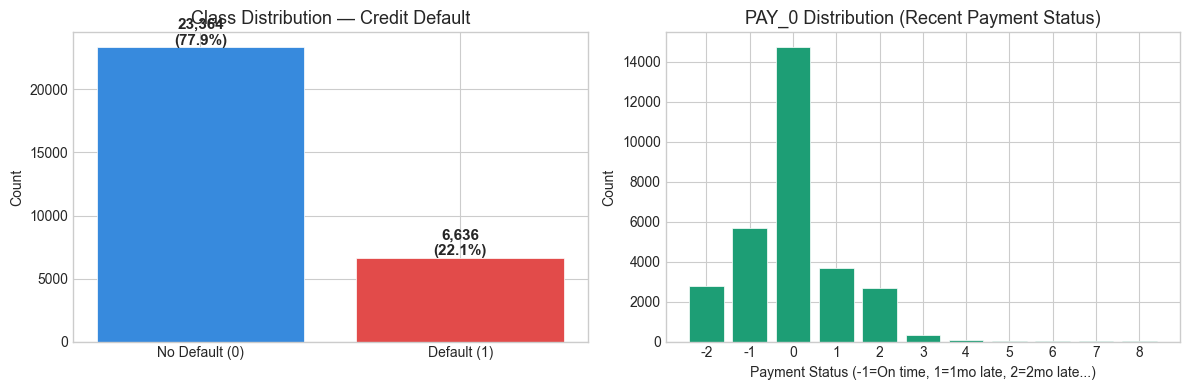


Class imbalance ratio: 77.9% vs 22.1%
For every 1 default, there are 3.5 non-defaults


In [7]:
# Count defaults vs non-defaults
default_counts = df['default'].value_counts()
default_pct = df['default'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['No Default (0)', 'Default (1)'],
            default_counts.values,
            color=['#378ADD', '#E24B4A'],
            edgecolor='white', linewidth=0.5)
axes[0].set_title('Class Distribution — Credit Default', fontsize=13)
axes[0].set_ylabel('Count')
for i, (count, pct) in enumerate(zip(default_counts.values, default_pct.values)):
    axes[0].text(i, count + 200, f'{count:,}\n({pct:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')

# Payment status distribution (PAY_0 — most predictive feature)
pay0_counts = df['PAY_0'].value_counts().sort_index()
axes[1].bar(pay0_counts.index.astype(str), pay0_counts.values,
            color='#1D9E75', edgecolor='white', linewidth=0.5)
axes[1].set_title('PAY_0 Distribution (Recent Payment Status)', fontsize=13)
axes[1].set_xlabel('Payment Status (-1=On time, 1=1mo late, 2=2mo late...)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../outputs/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nClass imbalance ratio: {default_pct[0]:.1f}% vs {default_pct[1]:.1f}%")
print(f"For every 1 default, there are {default_counts[0]/default_counts[1]:.1f} non-defaults")

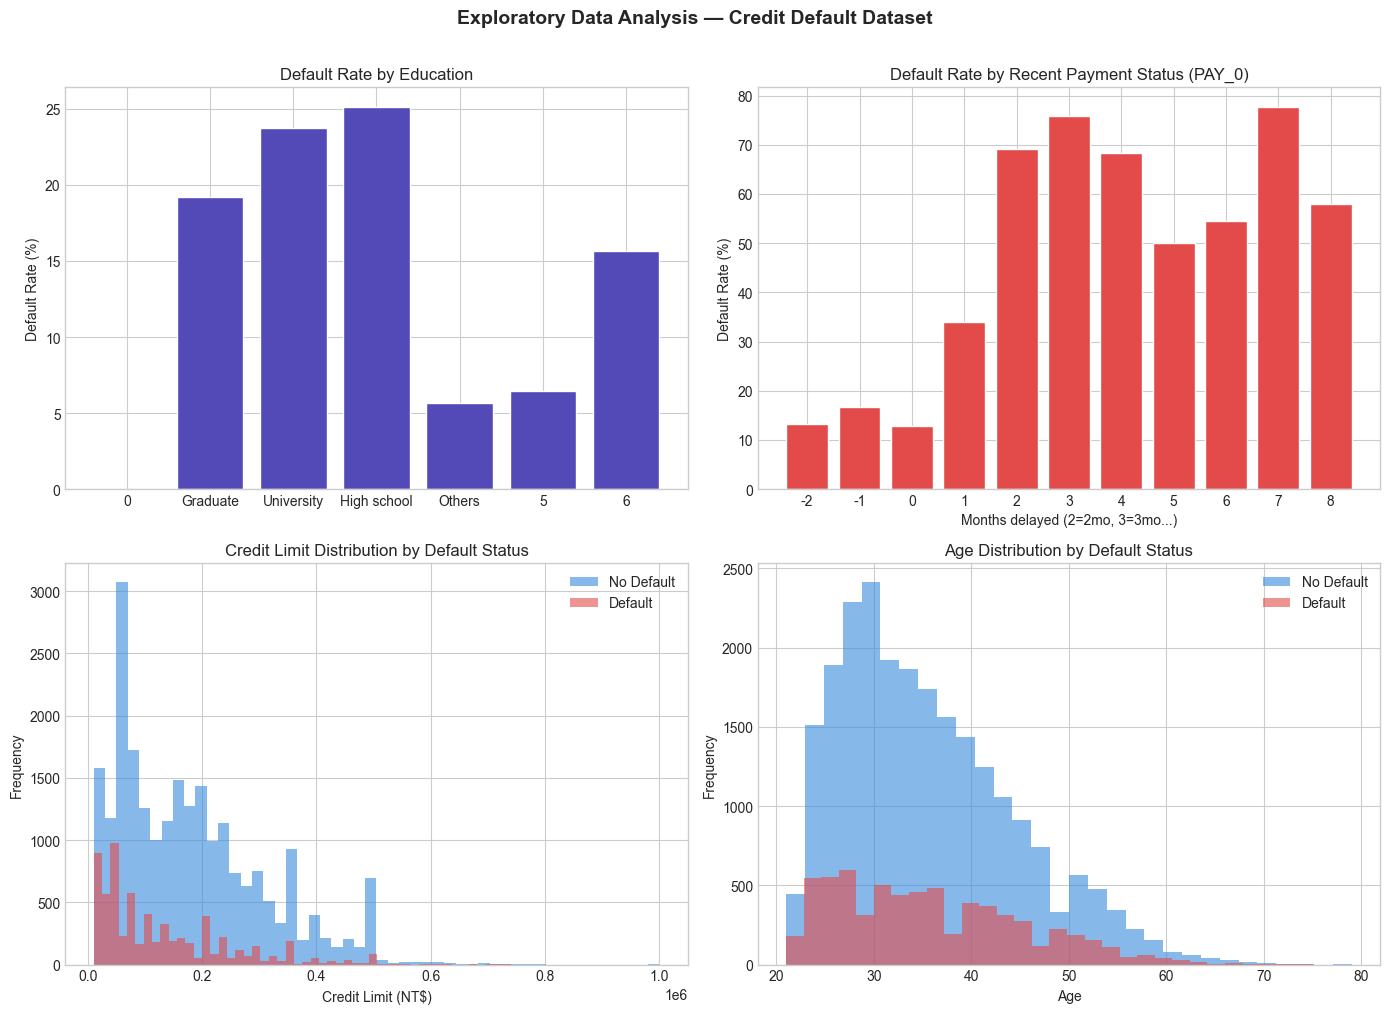

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Default rate by education level
edu_default = df.groupby('EDUCATION')['default'].mean() * 100
edu_labels = {1: 'Graduate', 2: 'University', 3: 'High school', 4: 'Others'}
edu_default.index = [edu_labels.get(i, str(i)) for i in edu_default.index]
axes[0,0].bar(edu_default.index, edu_default.values, color='#534AB7', edgecolor='white')
axes[0,0].set_title('Default Rate by Education', fontsize=12)
axes[0,0].set_ylabel('Default Rate (%)')

# 2. Default rate by PAY_0 (most recent payment delay)
pay_default = df.groupby('PAY_0')['default'].mean() * 100
axes[0,1].bar(pay_default.index.astype(str), pay_default.values,
              color='#E24B4A', edgecolor='white')
axes[0,1].set_title('Default Rate by Recent Payment Status (PAY_0)', fontsize=12)
axes[0,1].set_ylabel('Default Rate (%)')
axes[0,1].set_xlabel('Months delayed (2=2mo, 3=3mo...)')

# 3. Credit limit distribution by default status
df[df['default']==0]['LIMIT_BAL'].plot(kind='hist', bins=50, alpha=0.6,
    color='#378ADD', label='No Default', ax=axes[1,0])
df[df['default']==1]['LIMIT_BAL'].plot(kind='hist', bins=50, alpha=0.6,
    color='#E24B4A', label='Default', ax=axes[1,0])
axes[1,0].set_title('Credit Limit Distribution by Default Status', fontsize=12)
axes[1,0].set_xlabel('Credit Limit (NT$)')
axes[1,0].legend()

# 4. Age distribution by default status
df[df['default']==0]['AGE'].plot(kind='hist', bins=30, alpha=0.6,
    color='#378ADD', label='No Default', ax=axes[1,1])
df[df['default']==1]['AGE'].plot(kind='hist', bins=30, alpha=0.6,
    color='#E24B4A', label='Default', ax=axes[1,1])
axes[1,1].set_title('Age Distribution by Default Status', fontsize=12)
axes[1,1].set_xlabel('Age')
axes[1,1].legend()

plt.suptitle('Exploratory Data Analysis — Credit Default Dataset', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## EDA Key Findings

1. **Class imbalance**: ~78% non-default vs ~22% default. 
   This means we CANNOT use accuracy as our metric — a model that 
   always predicts "no default" gets 78% accuracy but is completely useless.
   → We will use **ROC-AUC** and track **recall on defaulters**.

2. **PAY_0 is critical**: Customers with 2+ month payment delays 
   have a default rate above 60%. This feature alone is highly predictive.
   → SHAP will confirm this in Stage 5.

3. **Credit limit is protective**: Customers with higher credit limits 
   default less — banks give higher limits to more reliable customers.
   → This creates a negative SHAP contribution (protective factor).

4. **Age has weak signal**: Distributions overlap heavily between 
   defaulters and non-defaulters. Weak feature on its own.

In [9]:
# Drop ID — it's just a row number, no predictive value
df.drop('ID', axis=1, inplace=True)

# === FEATURE ENGINEERING ===
# Create credit utilisation ratio — how much of their limit are they using?
# This is a concept your CDT research would group as "credit utilisation behaviour"
# High utilisation = spending close to limit = financial stress signal

df['util_ratio_1'] = df['BILL_AMT1'] / (df['LIMIT_BAL'] + 1)  # +1 avoids divide by zero
df['util_ratio_2'] = df['BILL_AMT2'] / (df['LIMIT_BAL'] + 1)
df['util_ratio_3'] = df['BILL_AMT3'] / (df['LIMIT_BAL'] + 1)

# Average payment ratio — how much of their bill do they actually pay?
# PAY_AMT / BILL_AMT close to 1.0 = responsible payer
# Close to 0.0 = paying minimum or nothing = risk signal
df['pay_ratio_1'] = df['PAY_AMT1'] / (df['BILL_AMT1'] + 1)
df['pay_ratio_2'] = df['PAY_AMT2'] / (df['BILL_AMT2'] + 1)
df['pay_ratio_3'] = df['PAY_AMT3'] / (df['BILL_AMT3'] + 1)

# Cap extreme ratios (someone paying 10x their bill = data quirk, not a real signal)
for col in ['util_ratio_1','util_ratio_2','util_ratio_3',
            'pay_ratio_1','pay_ratio_2','pay_ratio_3']:
    df[col] = df[col].clip(-2, 5)

print(f"Shape after feature engineering: {df.shape}")
print(f"\nNew features added:")
print(df[['util_ratio_1','pay_ratio_1']].describe())

print(df.dtypes)


Shape after feature engineering: (30000, 30)

New features added:
       util_ratio_1  pay_ratio_1
count      30000.00     29992.00
mean           0.42         0.50
std            0.41         1.20
min           -0.62        -2.00
25%            0.02         0.03
50%            0.31         0.06
75%            0.83         0.26
max            5.00         5.00
LIMIT_BAL         int64
SEX               int64
EDUCATION         int64
MARRIAGE          int64
AGE               int64
PAY_0             int64
PAY_2             int64
PAY_3             int64
PAY_4             int64
PAY_5             int64
PAY_6             int64
BILL_AMT1         int64
BILL_AMT2         int64
BILL_AMT3         int64
BILL_AMT4         int64
BILL_AMT5         int64
BILL_AMT6         int64
PAY_AMT1          int64
PAY_AMT2          int64
PAY_AMT3          int64
PAY_AMT4          int64
PAY_AMT5          int64
PAY_AMT6          int64
default           int64
util_ratio_1    float64
util_ratio_2    float64
util_ratio_3 

In [10]:
# Check PAY_0 unique values — there are some undocumented values (-2, 0)
print("PAY_0 unique values:", sorted(df['PAY_0'].unique()))
print("PAY_2 unique values:", sorted(df['PAY_2'].unique()))

# Values -2 and 0 are not in the official documentation
# -2 appears to mean "no consumption" and 0 means "revolving credit used"
# Both are essentially non-delinquent states — we treat them like -1 (paid duly)
# This is a real data quality decision you'd make in production

for col in ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']:
    df[col] = df[col].replace(-2, -1)  # no consumption → paid duly
    # 0 stays as 0 (revolving credit — borderline state, keep distinct)

# Separate features and target
X = df.drop('default', axis=1)
y = df['default']

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"\nFeature names ({len(X.columns)}):")
print(list(X.columns))

PAY_0 unique values: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_2 unique values: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

Feature matrix shape: (30000, 29)
Target distribution:
default
0    23364
1     6636
Name: count, dtype: int64

Feature names (29):
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'util_ratio_1', 'util_ratio_2', 'util_ratio_3', 'pay_ratio_1', 'pay_ratio_2', 'pay_ratio_3']


In [11]:
#Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% train, 20% test
    random_state=42,     # reproducibility
    stratify=y           # preserve 78/22 ratio in BOTH splits
)

print("=== Split Summary ===")
print(f"Training set:  {X_train.shape[0]:,} rows")
print(f"Test set:      {X_test.shape[0]:,} rows")
print(f"\nClass balance in training set:")
print(y_train.value_counts(normalize=True).mul(100).round(1))
print(f"\nClass balance in test set:")
print(y_test.value_counts(normalize=True).mul(100).round(1))

# Confirm both splits have the same ~78/22 ratio
assert abs(y_train.mean() - y_test.mean()) < 0.01, "Stratification failed!"
print("\nStratification confirmed ✓ — both splits have same class ratio")

=== Split Summary ===
Training set:  24,000 rows
Test set:      6,000 rows

Class balance in training set:
default
0   77.90
1   22.10
Name: proportion, dtype: float64

Class balance in test set:
default
0   77.90
1   22.10
Name: proportion, dtype: float64

Stratification confirmed ✓ — both splits have same class ratio


## Preprocessing Summary

| Step | Decision | Reason |
|------|----------|--------|
| Drop ID | Removed | Row number, no signal |
| Feature engineering | +6 ratio features | Normalise amounts, capture behaviour patterns |
| PAY_x = -2 → -1 | Recoded | Undocumented value, same meaning as "paid duly" |
| Train/test split | 80/20 stratified | Preserve class imbalance in both sets |
| Scaling | NOT applied | XGBoost is tree-based — does not need scaled features |

**Note on scaling:** Logistic Regression and SVMs need scaled features because 
they are sensitive to feature magnitude. XGBoost splits features at thresholds — 
it doesn't care if LIMIT_BAL is in the thousands and AGE is in the tens. 
Scaling would make no difference to the model but would make SHAP values 
harder to interpret. So we skip it deliberately.

In [12]:
#Training XGBOOST model and Evaluation

import xgboost as xgb
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, RocCurveDisplay)

model = xgb.XGBClassifier(
    n_estimators=250,        # number of trees
    max_depth=3,             # how deep each tree grows
    learning_rate=0.05,      # how much each tree corrects the previous
    subsample=0.8,           # use 80% of rows to train each tree
    colsample_bytree=0.8,    # use 80% of features per tree
    scale_pos_weight=3.5,    # compensates for 78/22 imbalance
    min_child_weight=5,      # minimum samples in a leaf node
    gamma=0.1,               # minimum loss reduction to make a split
    random_state=42,
    eval_metric='auc',
    use_label_encoder=False
)

# Train with early stopping — stops if AUC doesn't improve for 30 rounds
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    early_stopping_rounds=30,  # Added to enable best_iteration
    verbose=50    # prints progress every 50 trees
)

print("\nModel training complete ✓")
print(f"Best iteration: {model.best_iteration}")


[0]	validation_0-auc:0.75018	validation_1-auc:0.73465
[50]	validation_0-auc:0.78774	validation_1-auc:0.77335
[100]	validation_0-auc:0.79732	validation_1-auc:0.77846
[150]	validation_0-auc:0.80327	validation_1-auc:0.77990
[200]	validation_0-auc:0.80927	validation_1-auc:0.78024
[222]	validation_0-auc:0.81150	validation_1-auc:0.77997

Model training complete ✓
Best iteration: 193


In [13]:
# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # probability of default

# Core metrics
roc_auc = roc_auc_score(y_test, y_prob)

print("=" * 50)
print("MODEL EVALUATION REPORT")
print("=" * 50)
print(f"\nROC-AUC Score:  {roc_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['No Default', 'Default']))

# Confusion matrix breakdown
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix Breakdown:")
print(f"  True Negatives  (correctly said no default): {tn:,}")
print(f"  False Positives (wrongly flagged as default): {fp:,}")
print(f"  False Negatives (missed actual defaults):     {fn:,}")
print(f"  True Positives  (correctly caught defaults):  {tp:,}")
print(f"\n  → Of all actual defaulters, we caught: {tp/(tp+fn)*100:.1f}% (Recall)")
print(f"  → Of all we flagged, truly defaulted:  {tp/(tp+fp)*100:.1f}% (Precision)")

MODEL EVALUATION REPORT

ROC-AUC Score:  0.7804

Classification Report:
              precision    recall  f1-score   support

  No Default       0.88      0.80      0.84      4673
     Default       0.47      0.62      0.53      1327

    accuracy                           0.76      6000
   macro avg       0.68      0.71      0.69      6000
weighted avg       0.79      0.76      0.77      6000


Confusion Matrix Breakdown:
  True Negatives  (correctly said no default): 3,758
  False Positives (wrongly flagged as default): 915
  False Negatives (missed actual defaults):     510
  True Positives  (correctly caught defaults):  817

  → Of all actual defaulters, we caught: 61.6% (Recall)
  → Of all we flagged, truly defaulted:  47.2% (Precision)


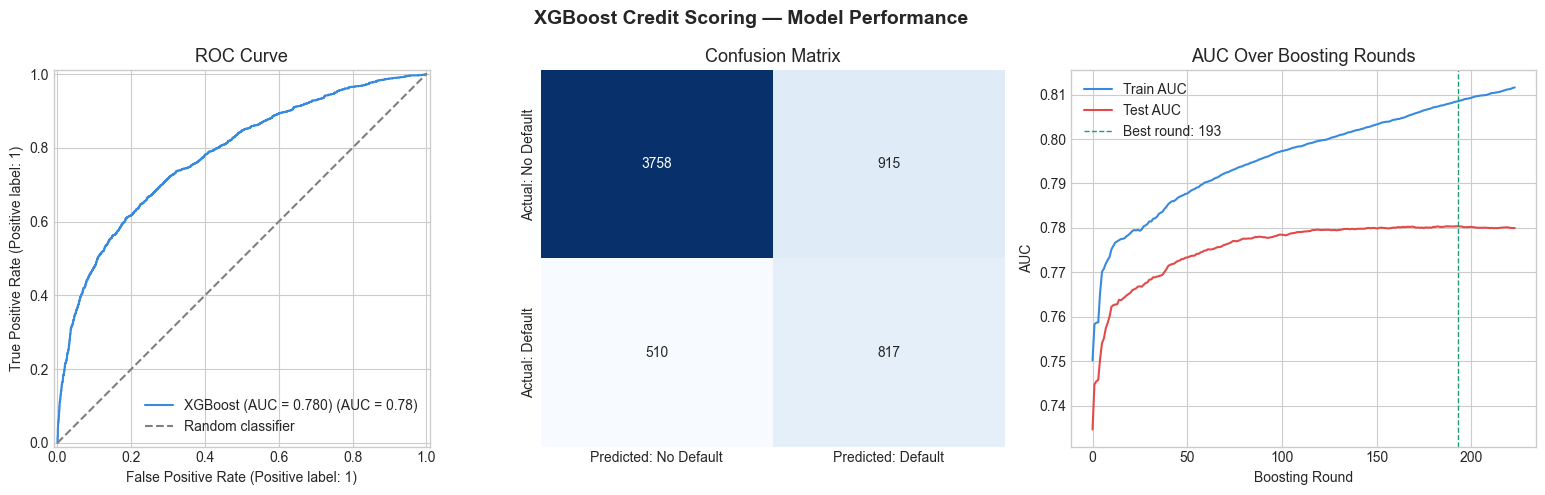


Plot saved to outputs/model_performance.png ✓


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: ROC Curve
RocCurveDisplay.from_predictions(
    y_test, y_prob, ax=axes[0],
    name=f'XGBoost (AUC = {roc_auc:.3f})',
    color='#378ADD'
)
axes[0].plot([0,1],[0,1],'--', color='gray', label='Random classifier')
axes[0].set_title('ROC Curve', fontsize=13)
axes[0].legend(fontsize=10)

# Plot 2: Confusion Matrix heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No Default','Predicted: Default'],
            yticklabels=['Actual: No Default','Actual: Default'],
            ax=axes[1], cbar=False)
axes[1].set_title('Confusion Matrix', fontsize=13)

# Plot 3: Training curve — AUC over boosting rounds
results = model.evals_result()
train_auc = results['validation_0']['auc']
test_auc  = results['validation_1']['auc']
rounds = range(len(train_auc))

axes[2].plot(rounds, train_auc, color='#378ADD', label='Train AUC', linewidth=1.5)
axes[2].plot(rounds, test_auc,  color='#E24B4A', label='Test AUC',  linewidth=1.5)
axes[2].set_title('AUC Over Boosting Rounds', fontsize=13)
axes[2].set_xlabel('Boosting Round')
axes[2].set_ylabel('AUC')
axes[2].legend()

# Mark best iteration
best = model.best_iteration
axes[2].axvline(x=best, color='#1D9E75', linestyle='--', linewidth=1,
                label=f'Best round: {best}')
axes[2].legend()

plt.suptitle('XGBoost Credit Scoring — Model Performance', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/model_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPlot saved to outputs/model_performance.png ✓")

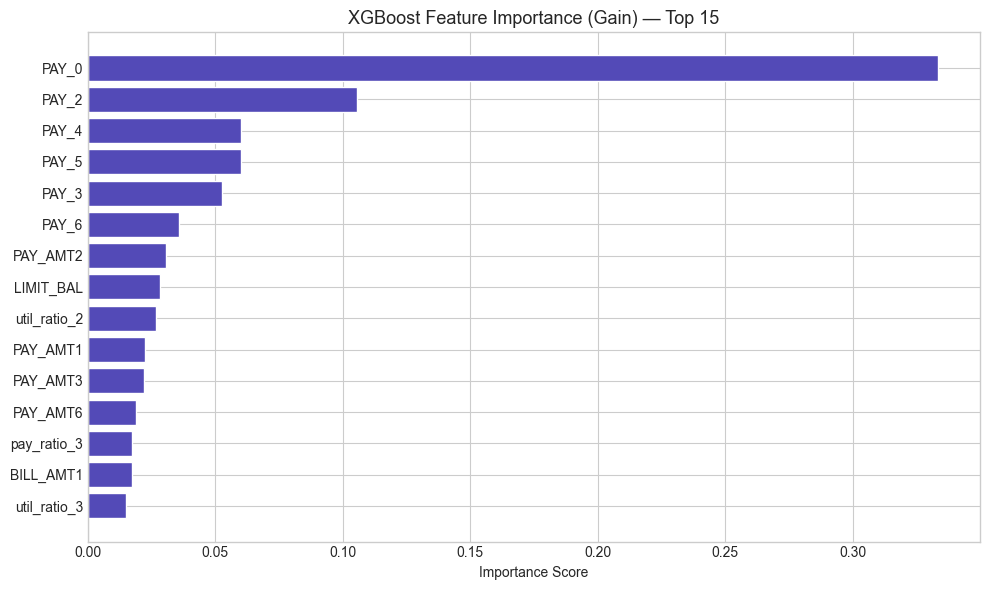


Top 5 features (XGBoost gain):
feature  importance
  PAY_0        0.33
  PAY_2        0.11
  PAY_4        0.06
  PAY_5        0.06
  PAY_3        0.05


In [15]:

# XGBoost's own feature importance — gain based
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'][::-1],
         importance_df['importance'][::-1],
         color='#534AB7', edgecolor='white')
plt.title("XGBoost Feature Importance (Gain) — Top 15", fontsize=13)
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig('../outputs/xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 features (XGBoost gain):")
print(importance_df.head(5).to_string(index=False))

## Why XGBoost importance is NOT enough — motivating SHAP

XGBoost's built-in feature importance (shown above) tells us which features 
were used most across all 300 trees. But it has two critical limitations:

1. **No direction** — it says PAY_0 is important, but does a high PAY_0 
   *increase* or *decrease* default risk? The plot cannot tell you.

2. **No per-customer explanation** — it gives one global ranking for all 
   30,000 customers. But Bank Manager Ravi needs to explain to Customer Priya 
   specifically *why her application was declined*.

This is exactly why SHAP was invented — and why it is required for 
RBI model risk compliance. Stage 5 fixes both limitations.

In [16]:
import shap

# TreeExplainer is optimised specifically for tree-based models (XGBoost, LightGBM, RF)
# It is exact (not approximate) — uses the tree structure directly
explainer = shap.TreeExplainer(model)

# Compute SHAP values for the entire test set
# This takes 1–2 minutes for 6,000 rows — normal
print("Computing SHAP values... (this takes ~1-2 minutes)")
shap_values = explainer.shap_values(X_test)

print(f"\nSHAP values shape: {shap_values.shape}")
print(f"  → {shap_values.shape[0]} customers × {shap_values.shape[1]} features")
print(f"\nExpected value (baseline): {explainer.expected_value:.4f}")
print(f"  → This is the model's average prediction across all training data")
print(f"  → Equivalent to: {shap_values.shape[0]} customers, average risk = {explainer.expected_value:.1%}")

Computing SHAP values... (this takes ~1-2 minutes)

SHAP values shape: (6000, 29)
  → 6000 customers × 29 features

Expected value (baseline): 0.0063
  → This is the model's average prediction across all training data
  → Equivalent to: 6000 customers, average risk = 0.6%


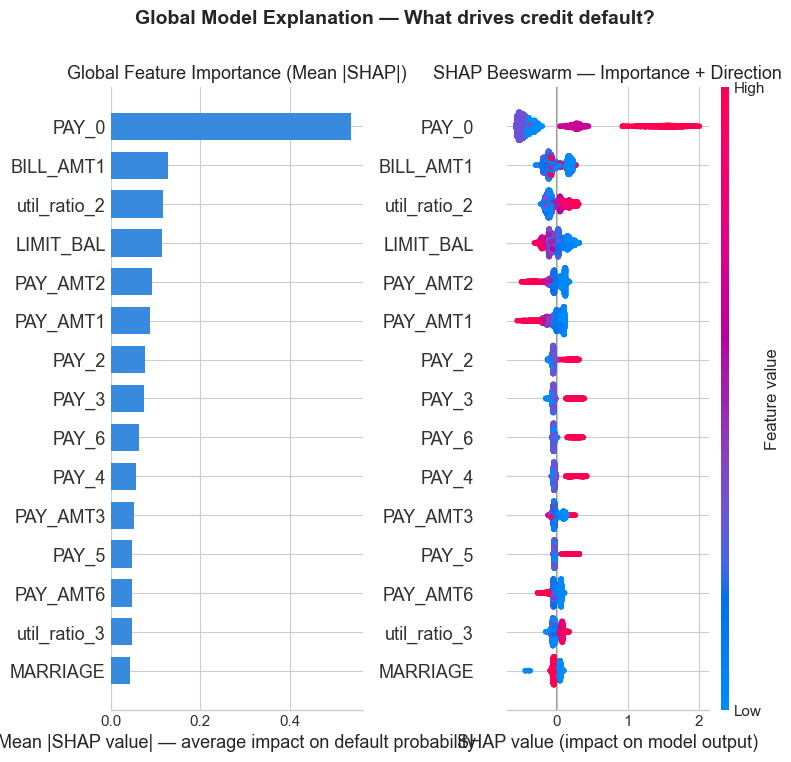

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Bar plot — mean absolute SHAP value per feature
# This is the SHAP version of feature importance
# Unlike XGBoost gain, this is in probability units — interpretable
plt.sca(axes[0])
shap.summary_plot(
    shap_values, X_test,
    plot_type="bar",
    max_display=15,
    show=False,
    color='#378ADD'
)
axes[0].set_title("Global Feature Importance (Mean |SHAP|)", fontsize=13)
axes[0].set_xlabel("Mean |SHAP value| — average impact on default probability")

# Plot 2: Beeswarm — shows BOTH importance AND direction
# Each dot = one customer
# Red dot = high feature value, Blue dot = low feature value
# Dot position on x-axis = SHAP value (how much it moved the prediction)
plt.sca(axes[1])
shap.summary_plot(
    shap_values, X_test,
    max_display=15,
    show=False
)
axes[1].set_title("SHAP Beeswarm — Importance + Direction", fontsize=13)

plt.suptitle("Global Model Explanation — What drives credit default?",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/shap_global.png', dpi=150, bbox_inches='tight')
plt.show()

CUSTOMER EXPLANATION — Index 28
Actual outcome:     Defaulted
Model prediction:   Default
Risk probability:   94.6%
Baseline (average): 0.6%
Risk increase:      +93.9% above baseline

Top 5 features pushing risk UP for this customer:
feature  shap_value  actual_value
  PAY_0        1.45          2.00
  PAY_2        0.26          2.00
  PAY_6        0.25          2.00
  PAY_3        0.19          2.00
  PAY_4        0.18          2.00

Top 5 features pushing risk DOWN (protective factors):
     feature  shap_value  actual_value
util_ratio_2       -0.01          0.12
   BILL_AMT5       -0.01      10571.00
    PAY_AMT6       -0.01       1300.00
 pay_ratio_1       -0.01          0.35
    PAY_AMT4       -0.02       1100.00


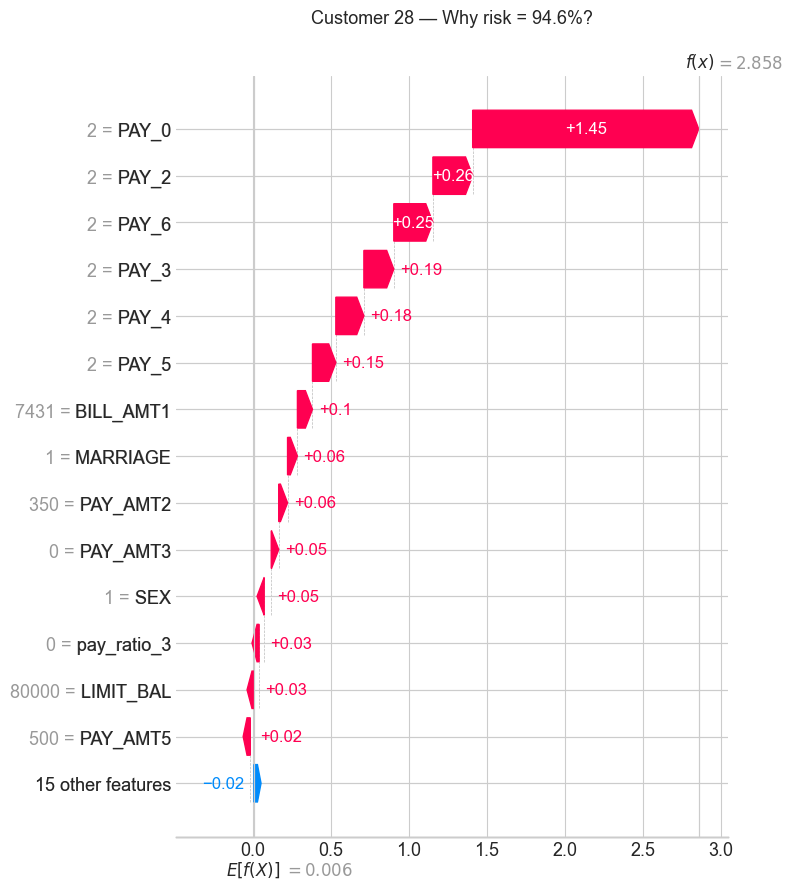

In [18]:
# Find an interesting customer — someone the model flagged as HIGH RISK
# who actually DID default (True Positive — model was correct)
high_risk_mask = (y_prob > 0.7) & (y_test.values == 1)
high_risk_idx = np.where(high_risk_mask)[0]

if len(high_risk_idx) > 0:
    customer_idx = high_risk_idx[0]
else:
    customer_idx = np.argmax(y_prob)  # fallback: highest risk customer

actual    = y_test.iloc[customer_idx]
predicted = model.predict(X_test.iloc[[customer_idx]])[0]
risk_prob = y_prob[customer_idx]

print("=" * 55)
print(f"CUSTOMER EXPLANATION — Index {customer_idx}")
print("=" * 55)
print(f"Actual outcome:     {'Defaulted' if actual == 1 else 'Did not default'}")
print(f"Model prediction:   {'Default' if predicted == 1 else 'No Default'}")
print(f"Risk probability:   {risk_prob:.1%}")
print(f"Baseline (average): {explainer.expected_value:.1%}")
print(f"Risk increase:      +{(risk_prob - explainer.expected_value):.1%} above baseline")

print(f"\nTop 5 features pushing risk UP for this customer:")
customer_shap = shap_values[customer_idx]
feature_shap  = pd.DataFrame({
    'feature':    X_test.columns,
    'shap_value': customer_shap,
    'actual_value': X_test.iloc[customer_idx].values
}).sort_values('shap_value', ascending=False)

print(feature_shap[feature_shap['shap_value'] > 0].head(5).to_string(index=False))

print(f"\nTop 5 features pushing risk DOWN (protective factors):")
print(feature_shap[feature_shap['shap_value'] < 0].tail(5).to_string(index=False))

# Waterfall plot — the most intuitive single-customer explanation
plt.figure(figsize=(12, 7))
shap.plots.waterfall(
    shap.Explanation(
        values         = shap_values[customer_idx],
        base_values    = explainer.expected_value,
        data           = X_test.iloc[customer_idx].values,
        feature_names  = X_test.columns.tolist()
    ),
    show=False,
    max_display=15
)
plt.title(f"Customer {customer_idx} — Why risk = {risk_prob:.1%}?",
          fontsize=13, pad=20)
plt.tight_layout()
plt.savefig('../outputs/shap_waterfall_customer.png',
            dpi=150, bbox_inches='tight')
plt.show()

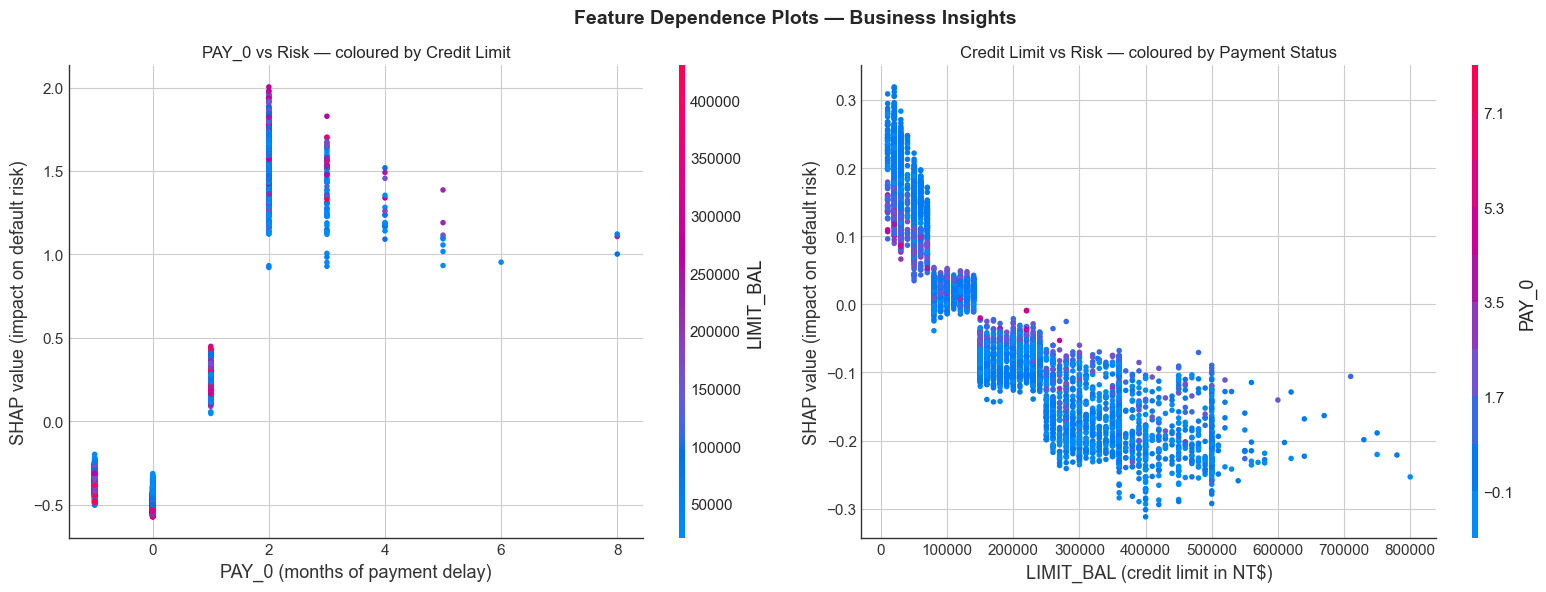

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: PAY_0 dependence — how payment delay drives risk
# interaction_index='LIMIT_BAL' colours dots by credit limit
# reveals: low-limit customers with payment delays are at HIGHEST risk
shap.dependence_plot(
    'PAY_0', shap_values, X_test,
    interaction_index='LIMIT_BAL',
    ax=axes[0], show=False
)
axes[0].set_title("PAY_0 vs Risk — coloured by Credit Limit", fontsize=12)
axes[0].set_xlabel("PAY_0 (months of payment delay)")
axes[0].set_ylabel("SHAP value (impact on default risk)")

# Plot 2: LIMIT_BAL dependence — how credit limit affects risk
# interaction_index='PAY_0' colours by payment behaviour
shap.dependence_plot(
    'LIMIT_BAL', shap_values, X_test,
    interaction_index='PAY_0',
    ax=axes[1], show=False
)
axes[1].set_title("Credit Limit vs Risk — coloured by Payment Status", fontsize=12)
axes[1].set_xlabel("LIMIT_BAL (credit limit in NT$)")
axes[1].set_ylabel("SHAP value (impact on default risk)")

plt.suptitle("Feature Dependence Plots — Business Insights",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

## business Insights
Customers with 2+ months of payment delay AND a low credit limit are at the absolute highest default risk — the two risk factors compound each other. Customers with the same payment delay but a high credit limit are somewhat protected — banks may have given them flexibility for a reason. This interaction is invisible in the XGBoost importance plot. SHAP reveals it in one picture.


## From SHAP Features to CDT Concepts — My M.E. Research Connection

SHAP operates at the **feature level**. It tells us:
> "PAY_0 contributed +0.31 to this customer's risk score"

A bank compliance officer cannot act on this directly. They think in **concepts**:
> "This customer showed poor recent payment behaviour"



### How CDT groups SHAP features into concepts:

| Concept | Features grouped | Business meaning |
|---------|-----------------|-----------------|
| Payment behaviour | PAY_0, PAY_2, PAY_3, PAY_4, PAY_5, PAY_6 | Has the customer been paying on time? |
| Credit utilisation | util_ratio_1, util_ratio_2, util_ratio_3 | How close to their limit are they spending? |
| Repayment capacity | pay_ratio_1, pay_ratio_2, pay_ratio_3 | What fraction of their bill do they actually pay? |
| Credit worthiness | LIMIT_BAL, EDUCATION, MARRIAGE | Background trust indicators |
| Spending pattern | BILL_AMT1–6 | Volume and trend of spending |

### Result
Instead of: *"PAY_0 = +0.31, LIMIT_BAL = -0.18, BILL_AMT1 = +0.09..."*  
CDT produces: *"Primary risk driver: poor payment behaviour (high confidence)"*

This is what RBI model risk guidelines mean by **"explainability to stakeholders"**.  
SHAP is the technical layer. CDT is the business layer. My research builds the bridge.